In [3]:
import re
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import bulk_vs_singlecell_matrix_viz, all_samples_matrix_viz

In [4]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "BAMixChecker"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1

# Data munging

## Similarity matrix

In [5]:
if pseudobulk:
    bamixchecker_df = pd.read_csv(
        DATA_PATH + 
        f"2b_bamixchecker/{dataset}/pseudobulk/ncells_{ncells}/BAMixChecker/Total_result.txt", 
        sep="\t", index_col=0, header=None
    )
else:
    bamixchecker_df = pd.read_csv(
        DATA_PATH + 
        f"2b_bamixchecker/{dataset}/real_data/ncells_null/BAMixChecker/Total_result.txt", 
        sep="\t", index_col=0, header=None
    )
    
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [6]:
if dataset == "hgsoc":
    regex_exp = r"[a-zA-Z0-9]{32}_"
elif dataset == "low_grade_glioma":
    regex_exp = r"^GSM[0-9]{7}_"

bamixchecker_dict = {
    x: 
    re.sub(regex_exp, "", x.replace("_filtered_rg.bam", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [7]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_3,0.0,Unmatched
pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_1,0.0,Unmatched
pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_1,0.0,Unmatched
pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_2,0.0,Unmatched
pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_3,0.0,Unmatched


In [8]:
def long_df_to_matrix_bamixchecker(df, metric="Concordance Rate"):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values=metric,
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [9]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [10]:
bamixchecker_matrix.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326880_ncells_100000_2,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326880_ncells_100000_3,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326881_ncells_100000_1,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326881_ncells_100000_2,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Sample matches

In [11]:
inferred_matches = long_df_to_matrix_bamixchecker(bamixchecker_df, "Conclusion").replace("Unmatched", 0).replace("Matched", 1).fillna(0)

In [12]:
inferred_matches.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Real data viz & analysis

/Users/lathouwe/Documents/HGSOC/hgsoc-power/sample_id_matching/scripts/experiment/analysis_shared_functions.py:123: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  cax = ax.matshow(sub_matrix, cmap=cmap)


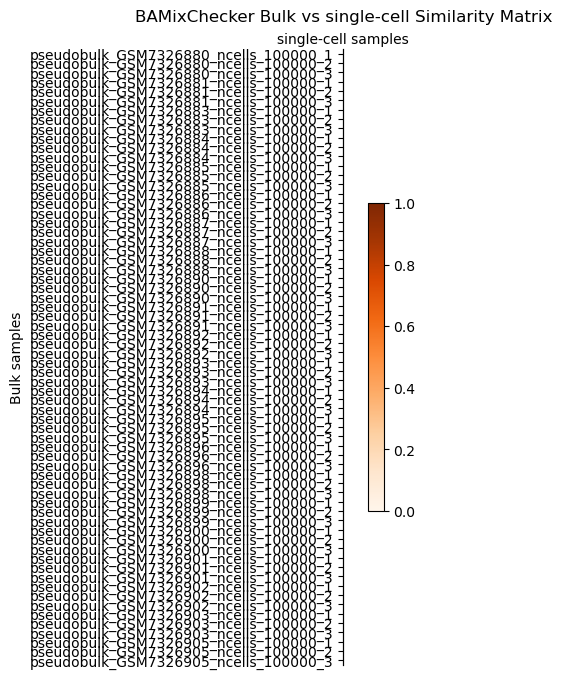

In [13]:
bulk_vs_singlecell_matrix_viz(
    bamixchecker_matrix,
    pseudobulk=pseudobulk,
    tool=tool,
    dataset=dataset,
    ncells=ncells,
    rd=rd,
    save_fig=False
)

## Comparison with expected matches

# Pseudobulk viz & analysis

In [14]:
# Filter BAMixChecker matrix to only samples ending in _1 in rows and samples ending in _2 in columns
pseudobulk_1 = "_1"
pseudobulk_2 = "_2"
pseudobulk_regex = r"_[1-3]{1}$"
bamixchecker_matrix_filtered = bamixchecker_matrix.loc[
    [idx for idx in bamixchecker_matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in bamixchecker_matrix.columns if col.endswith(pseudobulk_2)]
]

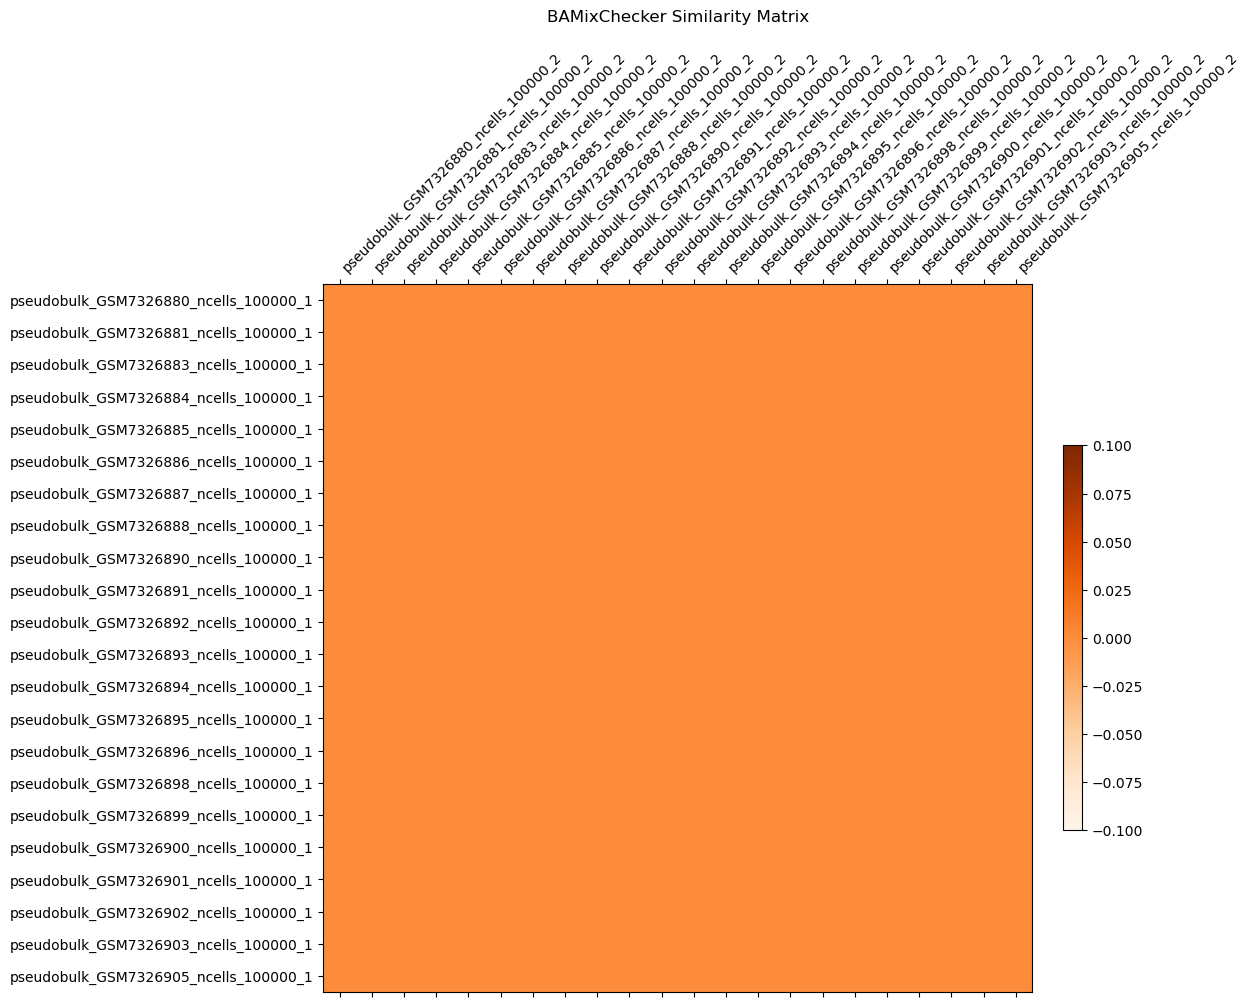

In [15]:
all_samples_matrix_viz(
    bamixchecker_matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

## Detailed accuracy metrics

In [16]:
inferred_matches.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Create inferred_matches matrix for submatrix 
inferred_matches_submatrix = inferred_matches.loc[
    [idx for idx in inferred_matches.index if idx.endswith(pseudobulk_1)],
    [col for col in inferred_matches.columns if col.endswith(pseudobulk_2)]
]
inferred_matches_submatrix.columns = pd.Index(inferred_matches_submatrix.columns, name="RIGHT_SAMPLE")

In [18]:
inferred_matches_submatrix.head()

RIGHT_SAMPLE,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326884_ncells_100000_2,pseudobulk_GSM7326885_ncells_100000_2,pseudobulk_GSM7326886_ncells_100000_2,pseudobulk_GSM7326887_ncells_100000_2,pseudobulk_GSM7326888_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_2,pseudobulk_GSM7326891_ncells_100000_2,...,pseudobulk_GSM7326894_ncells_100000_2,pseudobulk_GSM7326895_ncells_100000_2,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326898_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326900_ncells_100000_2,pseudobulk_GSM7326901_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_2
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326883_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326884_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326885_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(inferred_matches_submatrix)),
    index=pd.Index(inferred_matches_submatrix.index, name="pseudobulk_1"), 
    columns=pd.Index(inferred_matches_submatrix.columns, name="pseudobulk_2"),
    )

In [20]:
# Melt matrices into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])
inferred_matches_long = inferred_matches_submatrix.stack().rename("match").reset_index().set_index([0, "RIGHT_SAMPLE"])

inferred_matches_long["match"] = inferred_matches_long["match"].astype(float)

In [21]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, inferred_matches_long).ravel().tolist()

In [22]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
if tp + fp > 0:
    precision = tp / (tp + fp)
else:
    precision = np.nan
recall = tp / (tp + fn)
if precision and recall:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = tp / (2 * tp + fn + fp)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.95
Balanced accuracy = 0.50
Precision = nan
Recall = 0.00
F1 = 0.00
